Python port of biodiversity_code.R

Kenya insect-diversity SDM: compares 4 environmental-predictor scenarios
(GeoMAD, GeoMAD_Climate_Canopy_HF, TCI, TCI_Climate_Canopy_HF) using a
Random Forest presence/background model, with a full set of
publication-quality diagnostic figures per scenario plus a cross-scenario
comparison at the end.

The input paths
(/outputs/Shapefiles/Kenya.shp, the 4 scenario raster folders). All scenarios,
including GeoMAD, read the locally saved rasters in their folder (and its
subfolders) the same way - the GeoMAD files are already 2020-2023 composites,
so nothing is fetched with datacube.load() or averaged here. No VIF step is applied:
every non-empty, non-constant predictor is passed to the Random Forest.
The translation is faithful to the R logic, but
a few pieces don't have an exact library-for-library equivalent; see the
inline notes at each:
  - randomForest's importance="MeanDecreaseAccuracy" -> sklearn's
    permutation_importance (built-in .feature_importances_ is Gini-based,
    i.e. closer to MeanDecreaseGini, not MeanDecreaseAccuracy)
  - ggplot2/patchwork/corrplot styling -> matplotlib, approximated, not
    pixel-identical
  - terra::cellSize (geodesic area) -> simple planar pixel-area from the
    transform, correct if the scenario rasters are in a projected CRS in
    metres (the "_250M" folder names suggest they are) but not
    geodetically exact if they turn out to be in a geographic CRS

In [1]:
import os
import pickle
import platform
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.transform
from rasterio.warp import Resampling, reproject, calculate_default_transform
from rasterio.mask import mask as rio_mask
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, auc as sk_auc

## 1. SETUP

In [2]:
PALETTE_MAIN = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E", "#E6AB02"]
PALETTE_SCENARIO = ["#E66B4B", "#4B8DE6", "#E6D14B", "#8B4BE6"]

OCCURRENCE_FILE = "Data/Shapefiles/Kenya_presence_points.csv"
AOI_FILE = "Data/Shapefiles/Kenya.shp"
VERSION_NUMBER = "4"
OUTPUT_BASE_DIR = f"Data/Outputs_{VERSION_NUMBER}"
os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)
print(os.path.abspath(OUTPUT_BASE_DIR))
HUMAN_IMPACT_TIF = "Data/Kenya/HumanImpact.tif"  # wall-to-wall HFI used by the intactness sections

SCENARIO_PATHS = [
    "Data/Kenya/Kenya_Geomad_2020_2023_250M",
    "Data/Kenya/Kenya_Geomad_SPECTRAL_2020_2023_250M",
    "Data/Kenya/Kenya_TCI_2020_2023_250M",
    "Data/Kenya/Kenya_TCI_SPECTRAL_2020_2023_250M/RESAMPLED",
]
SCENARIO_NAMES = ["GeoMAD", "GeoMAD_Climate_Canopy_HF", "TCI", "TCI_Climate_Canopy_HF"]


for path in [OCCURRENCE_FILE, AOI_FILE, HUMAN_IMPACT_TIF, *SCENARIO_PATHS]:
    # counts .tif files in subfolders too, like the scenario loader in section 4
    n_tif = sum(f.lower().endswith(".tif") for _, _, fs in os.walk(path) for f in fs) if os.path.isdir(path) else None
    print(("OK      " if os.path.exists(path) else "MISSING ") + path + (f"  ({n_tif} .tif)" if n_tif is not None else ""))




/home/jovyan/insects_2/deafrica-sandbox-notebooks/Use_cases/Biodiversity/Data/Outputs_4
OK      Data/Shapefiles/Kenya_presence_points.csv
OK      Data/Shapefiles/Kenya.shp
OK      Data/Kenya/HumanImpact.tif
OK      Data/Kenya/Kenya_Geomad_2020_2023_250M  (13 .tif)
OK      Data/Kenya/Kenya_Geomad_SPECTRAL_2020_2023_250M  (13 .tif)
OK      Data/Kenya/Kenya_TCI_2020_2023_250M  (3 .tif)
OK      Data/Kenya/Kenya_TCI_SPECTRAL_2020_2023_250M/RESAMPLED  (7 .tif)


In [3]:
RNG_SEED = 42
np.random.seed(RNG_SEED)
TRAIN_TEST_SPLIT = 0.8

os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)


def log(*args):
    print(*args)


def apply_publication_style(ax, title=None, subtitle=None):
    """Approximates theme_publication(): bold axis titles, black border,
    light gridlines, subtitle as a smaller grey line under the title."""
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
    ax.grid(True, color="grey", alpha=0.25, linewidth=0.25)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontweight="bold", loc="left", fontsize=12)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, color="grey", fontsize=9)


performance_summary = []  # list of dicts, one per scenario -> DataFrame at the end

## 2. HELPER FUNCTIONS

In [4]:
def find_raster_files(folder):
    """All .tif/.asc/.img files in `folder` and its subfolders (unzipping often adds an extra
    folder level, e.g. X/X/*.tif), sorted so the load order is the same on every run."""
    if not os.path.isdir(folder):
        return []
    return sorted(
        os.path.join(root, f)
        for root, _, files in os.walk(folder)
        for f in files
        if f.lower().endswith((".tif", ".asc", ".img"))
    )


def get_spec_sens_threshold(observed, predicted):
    """Youden's J statistic: threshold maximizing (sensitivity + specificity - 1)."""
    fpr, tpr, thresholds = roc_curve(observed, predicted)
    j = tpr - fpr
    return thresholds[np.argmax(j)]


def get_confusion_metrics(actual, predicted_binary):
    actual = np.asarray(actual, dtype=int)
    predicted_binary = np.asarray(predicted_binary, dtype=int)

    tp = int(np.sum((predicted_binary == 1) & (actual == 1)))
    tn = int(np.sum((predicted_binary == 0) & (actual == 0)))
    fp = int(np.sum((predicted_binary == 1) & (actual == 0)))
    fn = int(np.sum((predicted_binary == 0) & (actual == 1)))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_score = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

    return {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sensitivity": sensitivity, "Specificity": specificity, "Accuracy": accuracy,
        "Precision": precision, "F1_Score": f1_score,
    }


def partial_dependence(model, train_df, predictor_cols, variable, grid_points=50):
    """Partial dependence for one variable: hold all others at the value of
    the first training row, sweep `variable` across its observed range."""
    var_range = (train_df[variable].min(), train_df[variable].max())
    grid_values = np.linspace(var_range[0], var_range[1], grid_points)

    base_row = train_df[predictor_cols].iloc[[0]]
    pred_data = pd.concat([base_row] * grid_points, ignore_index=True)
    pred_data[variable] = grid_values

    pred_probs = model.predict_proba(pred_data[predictor_cols])[:, 1]
    return pd.DataFrame({"Variable": variable, "Value": grid_values, "Probability": pred_probs})

## 3. LOAD OCCURRENCE AND AOI DATA

In [5]:
log("Loading occurrence data...")
occ_data = pd.read_csv(OCCURRENCE_FILE)
if "longitude" not in occ_data.columns or "latitude" not in occ_data.columns:
    raise ValueError("Occurrence data must contain 'longitude' and 'latitude' columns")

occ_sf_base = gpd.GeoDataFrame(
    occ_data, geometry=gpd.points_from_xy(occ_data.longitude, occ_data.latitude), crs="EPSG:4326"
)
log("Total occurrence points loaded:", len(occ_sf_base))

log("Loading AOI shapefile...")
aoi_base = gpd.read_file(AOI_FILE)
if aoi_base.crs is None:
    aoi_base = aoi_base.set_crs("EPSG:4326")

occ_sf_base = occ_sf_base.to_crs(aoi_base.crs)

points_in_aoi = occ_sf_base.geometry.intersects(aoi_base.geometry.union_all())
if points_in_aoi.sum() < len(occ_sf_base):
    log(f"Filtering {len(occ_sf_base) - points_in_aoi.sum()} points outside AOI...")
    occ_sf_base = occ_sf_base[points_in_aoi.to_numpy()]

n_presence = len(occ_sf_base)
log(f"Cleaned presence points in AOI: {n_presence}\n")


Loading occurrence data...
Total occurrence points loaded: 541
Loading AOI shapefile...
Cleaned presence points in AOI: 541



## 4. SCENARIO LOOP

In [6]:
for i, (scenario_name, rasters_path) in enumerate(zip(SCENARIO_NAMES, SCENARIO_PATHS), start=1):

    log("\n" + "=" * 70)
    log(f"SCENARIO ({i}/{len(SCENARIO_NAMES)}): {scenario_name}")
    log("=" * 70)

    scenario_output_dir = os.path.join(OUTPUT_BASE_DIR, scenario_name)
    os.makedirs(scenario_output_dir, exist_ok=True)

    # --- 4a. Load and align rasters ---
    raster_files = find_raster_files(rasters_path)
    if not raster_files:
        raise FileNotFoundError(
            f"No .tif/.asc/.img rasters in {os.path.abspath(rasters_path)} or its subfolders"
            + ("" if os.path.isdir(rasters_path) else " (the folder does not exist)")
            + f" - check SCENARIO_PATHS[{i - 1}] for {scenario_name}"
        )
    log(f"Loading {len(raster_files)} rasters from {rasters_path}:")

    band_arrays = {}   # name -> (array, transform, crs, nodata)
    for f in raster_files:
        try:
            with rasterio.open(f) as src:
                f_name = os.path.splitext(os.path.basename(f))[0]
                name = src.descriptions[0] or f_name
                arr = src.read(1).astype("float32")

                # population_mean -> clamp to 1000, rename to population_impact
                if name == "population_mean" or f_name == "population_mean":
                    log("  [Processing] Clamping 'population_mean' (>1000 -> 1000) and renaming to 'population_impact'...")
                    arr = np.clip(arr, None, 1000)
                    name = "population_impact"

                if name in band_arrays:
                    log(f"  WARNING: '{name}' appears twice - {os.path.relpath(f, rasters_path)} replaces the earlier file")
                log(f"  {name:<20} <- {os.path.relpath(f, rasters_path)}")
                band_arrays[name] = (arr, src.transform, src.crs, src.nodata)
        except Exception as e:
            log(f"  Could not read {f}: {e}")

    if not band_arrays:
        log(f"ERROR: Could not load any rasters for {scenario_name}")
        continue

    initial_vars = list(band_arrays.keys())
    var_display = ", ".join(initial_vars[:3]) + (" ..." if len(initial_vars) > 3 else "")
    log(f"Loaded {len(initial_vars)} variables: {var_display}")

    # Reference grid: prefer a band named like B02/B03/B04 (Sentinel-2 style), else the first
    ref_name = next((n for n in initial_vars if any(b in n for b in ("B02", "B03", "B04"))), initial_vars[0])
    ref_arr, ref_transform, ref_crs, ref_nodata = band_arrays[ref_name]
    ref_height, ref_width = ref_arr.shape
    log(f"Reference CRS: {ref_crs}")

    def align_to_ref(arr, transform, crs):
        if crs == ref_crs and arr.shape == ref_arr.shape and transform == ref_transform:
            return arr
        dest = np.full((ref_height, ref_width), np.nan, dtype="float32")
        reproject(
            source=arr, destination=dest,
            src_transform=transform, src_crs=crs,
            dst_transform=ref_transform, dst_crs=ref_crs,
            resampling=Resampling.bilinear,
        )
        return dest

    aligned = {}
    for name, (arr, transform, crs, nodata) in band_arrays.items():
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)
        if name == ref_name:
            aligned[name] = arr
        else:
            log(f"  Aligning {name}...")
            aligned[name] = align_to_ref(arr, transform, crs)

    env_names_all = list(aligned.keys())
    env_stack = np.stack([aligned[n] for n in env_names_all])

    # --- 4b. Crop/mask to AOI, drop empty / zero-variance layers (no VIF) ---
    log("Cropping, masking, and variable selection...")

    aoi_reproj = aoi_base.to_crs(ref_crs)
    stack_profile = {
        "driver": "GTiff", "height": ref_height, "width": ref_width, "count": len(env_names_all),
        "dtype": "float32", "crs": ref_crs, "transform": ref_transform, "nodata": np.nan,
    }
    from rasterio.io import MemoryFile
    with MemoryFile() as memfile:
        with memfile.open(**stack_profile) as tmp:
            tmp.write(env_stack.astype("float32"))
        with memfile.open() as tmp:
            masked, masked_transform = rio_mask(tmp, aoi_reproj.geometry, crop=True)

    # Audit empty layers
    valid_layers = [not np.all(np.isnan(masked[k])) for k in range(masked.shape[0])]
    empty_layers = [n for n, v in zip(env_names_all, valid_layers) if not v]
    if empty_layers:
        log("[Audit] Empty layers removed:", ", ".join(empty_layers))
    keep_idx = [k for k, v in enumerate(valid_layers) if v]
    env_stack_masked = masked[keep_idx]
    env_names_masked = [env_names_all[k] for k in keep_idx]

    # Extract values at occurrence locations
    occ_sf_reproj = occ_sf_base.to_crs(ref_crs)
    rows, cols = rasterio.transform.rowcol(masked_transform, occ_sf_reproj.geometry.x, occ_sf_reproj.geometry.y)
    rows, cols = np.array(rows), np.array(cols)
    h, w = env_stack_masked.shape[1], env_stack_masked.shape[2]
    in_bounds = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)

    occ_env_values = pd.DataFrame(np.nan, index=range(len(occ_sf_reproj)), columns=env_names_masked)
    for j, name in enumerate(env_names_masked):
        vals = np.full(len(occ_sf_reproj), np.nan)
        vals[in_bounds] = env_stack_masked[j][rows[in_bounds], cols[in_bounds]]
        occ_env_values[name] = vals

    na_counts = occ_env_values.isna().sum()
    vars_with_na = na_counts[na_counts > 0]
    if len(vars_with_na) > 0:
        log("[Audit] Variables with NAs at occurrence points:")
        for v, c in vars_with_na.items():
            log(f"  {v}: {c}/{len(occ_env_values)} points")

    occ_env_complete = occ_env_values.dropna()
    print(occ_env_complete)
    log(f"Complete cases at occurrence points: {len(occ_env_complete)}/{len(occ_env_values)} points")

    var_check = occ_env_complete.var()
    zero_var_cols = var_check[(var_check == 0) | var_check.isna()].index.tolist()
    if zero_var_cols:
        log("[Audit] Zero-variance variables removed:", ", ".join(zero_var_cols))
        occ_env_complete = occ_env_complete.drop(columns=zero_var_cols)

    retained_names = list(occ_env_complete.columns)

    sel_idx = [env_names_masked.index(v) for v in retained_names]
    env_stack_selected = env_stack_masked[sel_idx]
    selected_predictor_names = retained_names

    accounted_for = set(selected_predictor_names) | set(empty_layers) | set(zero_var_cols)
    unaccounted = [v for v in initial_vars if v not in accounted_for]

    log("------ VARIABLE ACCOUNTING ------")
    log(f"Retained ({len(selected_predictor_names)}): {', '.join(selected_predictor_names)}")
    log(f"Zero-Variance ({len(zero_var_cols)}): {', '.join(zero_var_cols) if zero_var_cols else 'None'}")
    log(f"Empty/NA Layers ({len(empty_layers)}): {', '.join(empty_layers) if empty_layers else 'None'}")
    log("---------------------------------")

    # --- 4c. Background sampling and train/test split ---
    log(f"Sampling {n_presence} background points...")

    valid_mask = np.all(np.isfinite(env_stack_selected), axis=0)
    valid_rows, valid_cols = np.where(valid_mask)
    rng = np.random.default_rng(RNG_SEED)
    n_bg = n_presence - 250
    bg_choice = rng.choice(len(valid_rows), size=min(n_bg, len(valid_rows)), replace=False)
    bg_r, bg_c = valid_rows[bg_choice], valid_cols[bg_choice]

    def extract_at_rc(stack, rr, cc, names):
        df = pd.DataFrame(index=range(len(rr)), columns=names, dtype="float64")
        for j, name in enumerate(names):
            df[name] = stack[j][rr, cc]
        return df

    occ_vals = extract_at_rc(env_stack_selected, rows, cols, selected_predictor_names)
    occ_vals = occ_vals[in_bounds].reset_index(drop=True)
    occ_vals["presence"] = 1

    bg_vals = extract_at_rc(env_stack_selected, bg_r, bg_c, selected_predictor_names)
    bg_vals["presence"] = 0

    combined_data = pd.concat([occ_vals, bg_vals], ignore_index=True).dropna()
    combined_data["presence"] = combined_data["presence"].astype(int)

    idx_0 = combined_data.index[combined_data.presence == 0].to_numpy()
    idx_1 = combined_data.index[combined_data.presence == 1].to_numpy()
    rng.shuffle(idx_0)
    rng.shuffle(idx_1)
    train_idx = np.concatenate([
        idx_0[: int(np.floor(TRAIN_TEST_SPLIT * len(idx_0)))],
        idx_1[: int(np.floor(TRAIN_TEST_SPLIT * len(idx_1)))],
    ])
    test_idx = combined_data.index.difference(train_idx)
    print(train_idx)

    train_data = combined_data.loc[train_idx].reset_index(drop=True)
    test_data = combined_data.loc[test_idx].reset_index(drop=True)
    pred_cols = [c for c in train_data.columns if c != "presence"]

    log(f"Training data: {len(train_data)} (presence: {(train_data.presence==1).sum()}, absence: {(train_data.presence==0).sum()})")
    log(f"Test data: {len(test_data)} (presence: {(test_data.presence==1).sum()}, absence: {(test_data.presence==0).sum()})")

    # --- 4d. Train Random Forest ---
    log("Training Random Forest model...")
    rf_model = RandomForestClassifier(
        n_estimators=500, max_features=max(1, int(np.floor(np.sqrt(len(pred_cols))))),
        random_state=RNG_SEED,
    )
    rf_model.fit(train_data[pred_cols], train_data["presence"])

    with open(os.path.join(scenario_output_dir, "rf_model.pkl"), "wb") as f:
        pickle.dump(rf_model, f)
    with open(os.path.join(scenario_output_dir, "selected_predictors.pkl"), "wb") as f:
        pickle.dump(selected_predictor_names, f)

    # --- 4e. Model evaluation ---
    p_test_num = test_data["presence"].to_numpy()
    rf_pred_prob = rf_model.predict_proba(test_data[pred_cols])[:, 1]

    fpr, tpr, _ = roc_curve(p_test_num, rf_pred_prob)
    rf_auc = sk_auc(fpr, tpr)

    rf_threshold = get_spec_sens_threshold(p_test_num, rf_pred_prob)
    rf_pred_binary = (rf_pred_prob > rf_threshold).astype(int)
    rf_metrics = get_confusion_metrics(p_test_num, rf_pred_binary)

    log(
        f"Model Performance -> AUC: {rf_auc:.4f} | Sens: {rf_metrics['Sensitivity']:.4f} | "
        f"Spec: {rf_metrics['Specificity']:.4f} | Acc: {rf_metrics['Accuracy']:.4f} | "
        f"Prec: {rf_metrics['Precision']:.4f} | F1: {rf_metrics['F1_Score']:.4f}"
    )

    # --- 4f. Spatial projection ---
    log("Projecting spatial insect diversity map...")
    n_bands, gh, gw = env_stack_selected.shape
    flat = env_stack_selected.reshape(n_bands, -1).T
    flat_df = pd.DataFrame(flat, columns=selected_predictor_names)
    valid_pix = flat_df.notna().all(axis=1).to_numpy()

    rf_diversity_flat = np.full(flat_df.shape[0], np.nan)
    if valid_pix.sum() > 0:
        rf_diversity_flat[valid_pix] = rf_model.predict_proba(flat_df.loc[valid_pix])[:, 1]
    rf_diversity = rf_diversity_flat.reshape(gh, gw)

    rf_threshold_75 = np.nanquantile(rf_diversity, 0.75)
    rf_high_diversity_75 = (rf_diversity > rf_threshold_75).astype("float32")
    rf_high_diversity_75[np.isnan(rf_diversity)] = np.nan

    # Pixel area (km^2). Correct for a projected (metres) CRS - see module docstring.
    pixel_area_km2 = abs(masked_transform.a * masked_transform.e) / 1e6
    rf_area = float(np.nansum(np.where(rf_high_diversity_75 == 1, pixel_area_km2, 0)))

    # --- 4g. Reproject outputs to EPSG:4326 and save ---
    log("Reprojecting final raster outputs to EPSG:4326...")
    dst_transform, dst_w, dst_h = calculate_default_transform(ref_crs, "EPSG:4326", gw, gh, *rasterio.transform.array_bounds(gh, gw, masked_transform))

    def reproject_to_4326(arr, resampling):
        dest = np.full((dst_h, dst_w), np.nan, dtype="float32")
        reproject(
            source=arr.astype("float32"), destination=dest,
            src_transform=masked_transform, src_crs=ref_crs,
            dst_transform=dst_transform, dst_crs="EPSG:4326",
            resampling=resampling,
        )
        return dest

    rf_diversity_4326 = reproject_to_4326(rf_diversity, Resampling.bilinear)
    rf_high_diversity_75_4326 = reproject_to_4326(rf_high_diversity_75, Resampling.nearest)

    performance_summary.append({
        "Scenario": scenario_name, "AUC": rf_auc, "Sensitivity": rf_metrics["Sensitivity"],
        "Specificity": rf_metrics["Specificity"], "Accuracy": rf_metrics["Accuracy"],
        "Precision": rf_metrics["Precision"], "F1_Score": rf_metrics["F1_Score"],
        "HighDiversityArea_km2": rf_area, "N_Predictors": len(selected_predictor_names),
    })

    out_profile_4326 = {
        "driver": "GTiff", "height": dst_h, "width": dst_w, "count": 1,
        "dtype": "float32", "crs": "EPSG:4326", "transform": dst_transform, "nodata": np.nan,
    }
    with rasterio.open(os.path.join(scenario_output_dir, f"{scenario_name}_Insect_Diversity.tif"), "w", **out_profile_4326) as dst:
        dst.write(rf_diversity_4326, 1)
    with rasterio.open(os.path.join(scenario_output_dir, f"{scenario_name}_High_Diversity_Threshold_75.tif"), "w", **out_profile_4326) as dst:
        dst.write(rf_high_diversity_75_4326, 1)

    # --- 4h. Figures ---

    # Fig 1A: predictor distributions
    log("Generating variable distribution plots...")
    n_vars = len(selected_predictor_names)
    n_cols = min(3, int(np.ceil(np.sqrt(n_vars))))
    n_rows = int(np.ceil(n_vars / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    axes = np.atleast_1d(axes).flatten()
    colors = cm.get_cmap("turbo")(np.linspace(0, 1, n_vars))
    for ax, var, color in zip(axes, selected_predictor_names, colors):
        ax.hist(train_data[var].dropna(), bins=30, color=color, edgecolor="black", linewidth=0.3, alpha=0.7)
        ax.set_title(var, fontweight="bold", fontsize=9)
        apply_publication_style(ax)
    for ax in axes[n_vars:]:
        ax.axis("off")
    fig.suptitle(f"A) Selected Predictor Distributions - {scenario_name}", fontweight="bold", x=0.02, ha="left")
    plt.tight_layout()
    plt.savefig(os.path.join(scenario_output_dir, "Fig1A_Variable_Distributions.pdf"))
    plt.savefig(os.path.join(scenario_output_dir, "Fig1A_Variable_Distributions.png"), dpi=300)
    plt.close(fig)

    # Fig 1B: correlation heatmap
    log("Generating correlation heatmap...")
    corr_matrix = train_data[selected_predictor_names].corr()
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(corr_matrix)))
    ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(corr_matrix)))
    ax.set_yticklabels(corr_matrix.columns, fontsize=8)
    for r in range(len(corr_matrix)):
        for c in range(len(corr_matrix)):
            ax.text(c, r, f"{corr_matrix.iloc[r, c]:.2f}", ha="center", va="center", fontsize=6)
    fig.colorbar(im, ax=ax)
    ax.set_title(f"B) Variable Correlation Matrix - {scenario_name}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(scenario_output_dir, "Fig1B_Correlation_Heatmap.pdf"))
    plt.savefig(os.path.join(scenario_output_dir, "Fig1B_Correlation_Heatmap.png"), dpi=300)
    plt.close(fig)

    # Fig 2: feature importance (permutation importance ~ MeanDecreaseAccuracy)
    log("Generating feature importance plot...")
    perm = permutation_importance(rf_model, test_data[pred_cols], test_data["presence"], scoring="accuracy", random_state=RNG_SEED, n_repeats=10)
    df_imp = pd.DataFrame({"Feature": pred_cols, "Importance": perm.importances_mean}).sort_values("Importance", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = cm.get_cmap("plasma")((df_imp["Importance"] - df_imp["Importance"].min()) / (df_imp["Importance"].max() - df_imp["Importance"].min() + 1e-9))
    ax.barh(df_imp["Feature"][::-1], df_imp["Importance"][::-1], color=colors[::-1], edgecolor="black", linewidth=0.4)
    ax.set_xlabel("Importance (permutation, accuracy)")
    ax.set_ylabel("Environmental Predictor")
    apply_publication_style(ax, title=f"C) Feature Importance - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(scenario_output_dir, "Fig2_Feature_Importance.pdf"))
    plt.savefig(os.path.join(scenario_output_dir, "Fig2_Feature_Importance.png"), dpi=300)
    plt.close(fig)

    # Fig 3: ROC curve
    log("Generating ROC curve...")
    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.plot(fpr, tpr, color="#D95F02", linewidth=1.2)
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=0.8)
    ax.scatter([1 - rf_metrics["Specificity"]], [rf_metrics["Sensitivity"]], color="red", s=60, marker="D", edgecolor="black", zorder=5)
    ax.text(0.55, 0.20, f"AUC = {rf_auc:.3f}\nThreshold = {rf_threshold:.3f}", fontsize=10, fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.8))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("1 - Specificity (False Positive Rate)")
    ax.set_ylabel("Sensitivity (True Positive Rate)")
    apply_publication_style(ax, title=f"D) ROC Curve - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(scenario_output_dir, "Fig3_ROC_Curve.pdf"))
    plt.savefig(os.path.join(scenario_output_dir, "Fig3_ROC_Curve.png"), dpi=300)
    plt.close(fig)

    # Fig 4: response curves for top 3 predictors
    log("Generating response curves for top predictors...")
    top_3_vars = df_imp["Feature"].iloc[: min(3, len(df_imp))].tolist()
    response_frames = [partial_dependence(rf_model, train_data, pred_cols, v, grid_points=50) for v in top_3_vars]
    response_data = pd.concat(response_frames, ignore_index=True)

    n_top = len(top_3_vars)
    fig, axes = plt.subplots(1, n_top, figsize=(10, 3.5))
    axes = np.atleast_1d(axes)
    colors = cm.get_cmap("viridis")(np.linspace(0, 1, n_top))
    for ax, var, color in zip(axes, top_3_vars, colors):
        sub = response_data[response_data.Variable == var]
        ax.plot(sub.Value, sub.Probability, color=color, linewidth=1.5)
        ax.fill_between(sub.Value, 0, sub.Probability, color=color, alpha=0.2)
        ax.set_title(var, fontsize=9, fontweight="bold")
        apply_publication_style(ax)
    fig.suptitle(f"E) Response Curves (Top {n_top} Predictors) - {scenario_name}", fontweight="bold", x=0.02, ha="left")
    fig.text(0.5, 0.02, "Predictor Value", ha="center")
    axes[0].set_ylabel("Predicted Presence Probability")
    plt.tight_layout()
    plt.savefig(os.path.join(scenario_output_dir, "Fig4_Response_Curves.pdf"))
    plt.savefig(os.path.join(scenario_output_dir, "Fig4_Response_Curves.png"), dpi=300)
    plt.close(fig)

    # Fig 5: spatial diversity map (EPSG:4326)
    log("Generating spatial diversity map in EPSG:4326...")
    occ_sf_4326 = occ_sf_reproj.to_crs("EPSG:4326")
    fig, ax = plt.subplots(figsize=(9, 8))
    extent = rasterio.transform.array_bounds(dst_h, dst_w, dst_transform)  # (left, bottom, right, top) order varies
    left, bottom, right, top = dst_transform.c, dst_transform.f + dst_h * dst_transform.e, dst_transform.c + dst_w * dst_transform.a, dst_transform.f
    im = ax.imshow(rf_diversity_4326, extent=(left, right, bottom, top), origin="upper", cmap="viridis")
    ax.scatter(occ_sf_4326.geometry.x, occ_sf_4326.geometry.y, color="red", s=8, alpha=0.6)
    fig.colorbar(im, ax=ax, label="Diversity Index")
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    apply_publication_style(
        ax, title=f"F) Insect Diversity Map - {scenario_name}",
        subtitle="CRS: WGS 84 (EPSG:4326) | Red points = occurrence observations",
    )
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(scenario_output_dir, "Fig5_Spatial_Diversity_Map.pdf"))
    plt.savefig(os.path.join(scenario_output_dir, "Fig5_Spatial_Diversity_Map.png"), dpi=300)
    plt.close(fig)

    # Fig 6: model diagnostics (predicted vs observed + confusion matrix)
    log("Generating model diagnostic plots...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    df_pred_obs = pd.DataFrame({"Observed": p_test_num, "Predicted": rf_pred_prob})
    for cls, color in ((0, "#1B9E77"), (1, "#D95F02")):
        sub = df_pred_obs[df_pred_obs.Observed == cls]
        jitter = sub.Observed + np.random.default_rng(RNG_SEED).uniform(-0.05, 0.05, len(sub))
        ax1.scatter(jitter, sub.Predicted, color=color, alpha=0.4, s=15, label="Presence" if cls else "Absence")
        ax1.boxplot(sub.Predicted, positions=[cls], widths=0.3, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.3), showfliers=False)
    ax1.axhline(rf_threshold, color="red", linestyle="--", linewidth=0.8)
    ax1.text(0.7, rf_threshold + 0.05, f"Threshold = {rf_threshold:.3f}", fontsize=8)
    ax1.set_xlabel("Observed Class (0 = Absence, 1 = Presence)")
    ax1.set_ylabel("Predicted Probability")
    ax1.legend(title="Observed Class")
    apply_publication_style(ax1, title=f"G) Model Predictions - {scenario_name}")

    conf_counts = np.array([[rf_metrics["TN"], rf_metrics["FN"]], [rf_metrics["FP"], rf_metrics["TP"]]])
    conf_pct = 100 * conf_counts / conf_counts.sum()
    im2 = ax2.imshow(conf_counts, cmap="Greens")
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(["Absence (0)", "Presence (1)"])
    ax2.set_yticks([0, 1]); ax2.set_yticklabels(["Absence (0)", "Presence (1)"])
    for r in range(2):
        for c in range(2):
            ax2.text(c, r, f"{conf_counts[r, c]}\n({conf_pct[r, c]:.1f}%)", ha="center", va="center", fontweight="bold")
    ax2.set_xlabel("Predicted"); ax2.set_ylabel("Actual")
    ax2.grid(False)
    apply_publication_style(ax2, title=f"H) Confusion Matrix - {scenario_name}")
    ax2.grid(False)

    plt.tight_layout()
    plt.savefig(os.path.join(scenario_output_dir, "Fig6_Model_Diagnostics.pdf"))
    plt.savefig(os.path.join(scenario_output_dir, "Fig6_Model_Diagnostics.png"), dpi=300)
    plt.close(fig)

    # Fig 7: performance metrics dashboard
    log("Generating performance metrics dashboard...")
    metrics_names = ["AUC", "Sensitivity", "Specificity", "Accuracy", "Precision", "F1-Score"]
    metrics_values = [rf_auc, rf_metrics["Sensitivity"], rf_metrics["Specificity"], rf_metrics["Accuracy"], rf_metrics["Precision"], rf_metrics["F1_Score"]]
    metrics_colors = ["#E66B4B", "#4B8DE6", "#E6D14B", "#8B4BE6", "#4BE66B", "#E64B8B"]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(metrics_names, metrics_values, color=metrics_colors, edgecolor="black", linewidth=0.5)
    for x, v in enumerate(metrics_values):
        ax.text(x, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontweight="bold")
    apply_publication_style(ax, title=f"I) Performance Metrics Summary - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(scenario_output_dir, "Fig7_Performance_Metrics.pdf"))
    plt.savefig(os.path.join(scenario_output_dir, "Fig7_Performance_Metrics.png"), dpi=300)
    plt.close(fig)

    # --- 4i. Model summary text ---
    top_lines = "\n".join(
        f"   {k+1}. {df_imp.Feature.iloc[k]} (Importance: {df_imp.Importance.iloc[k]:.4f})"
        for k in range(min(3, len(df_imp)))
    )
    summary_text = "\n".join([
        "1. STUDY DESIGN & DATA",
        f"   Occurrence Points (Presences): {n_presence}",
        f"   Background Points (Pseudo-absences): {n_presence}",
        f"   Training Set: {len(train_data)} samples ({100*TRAIN_TEST_SPLIT:.1f}% of total)",
        f"   Test Set: {len(test_data)} samples ({100*(1-TRAIN_TEST_SPLIT):.1f}% of total)",
        f"   Initial Environmental Variables: {len(initial_vars)}",
        "",
        "2. VARIABLE SELECTION & FEATURE ENGINEERING",
        "   Collinearity Screening: none (no VIF step)",
        f"   Final Retained Predictors ({len(selected_predictor_names)}): {', '.join(selected_predictor_names)}",
        f"   Zero-Variance Variables Removed ({len(zero_var_cols)}): {', '.join(zero_var_cols) if zero_var_cols else 'None'}",
        "",
        "3. RANDOM FOREST MODEL CONFIGURATION",
        "   Number of Trees: 500",
        f"   max_features (features per split): {max(1, int(np.floor(np.sqrt(len(pred_cols)))))}",
        f"   Random Seed: {RNG_SEED}",
        "",
        "4. MODEL PERFORMANCE EVALUATION",
        f"   Area Under ROC Curve (AUC): {rf_auc:.4f}",
        f"   Optimal Classification Threshold (Youden's J): {rf_threshold:.4f}",
        f"   Sensitivity (True Positive Rate): {rf_metrics['Sensitivity']:.4f}",
        f"   Specificity (True Negative Rate): {rf_metrics['Specificity']:.4f}",
        f"   Accuracy (Overall): {rf_metrics['Accuracy']:.4f}",
        f"   Precision (Positive Predictive Value): {rf_metrics['Precision']:.4f}",
        f"   F1-Score (Harmonic Mean): {rf_metrics['F1_Score']:.4f}",
        "   Confusion Matrix:",
        f"     True Negatives: {rf_metrics['TN']}, False Positives: {rf_metrics['FP']}",
        f"     False Negatives: {rf_metrics['FN']}, True Positives: {rf_metrics['TP']}",
        "",
        "5. SPATIAL PREDICTIONS",
        f"   High Insect Diversity Area (>75th Percentile): {rf_area:.2f} km²",
        f"   Diversity Index Range: {np.nanmin(rf_diversity_4326):.4f} to {np.nanmax(rf_diversity_4326):.4f}",
        "",
        "6. TOP 3 MOST IMPORTANT PREDICTORS",
        top_lines,
    ])
    with open(os.path.join(scenario_output_dir, "Model_Summary.txt"), "w") as f:
        f.write(summary_text)

    log(f"Completed scenario: {scenario_name}\n")


SCENARIO (1/4): GeoMAD
Loading 13 rasters from Data/Kenya/Kenya_Geomad_2020_2023_250M:
  B02                  <- B02_Kenya_2020_2023_avg.tif
  B03                  <- B03_Kenya_2020_2023_avg.tif
  B04                  <- B04_Kenya_2020_2023_avg.tif
  B05                  <- B05_Kenya_2020_2023_avg.tif
  B06                  <- B06_Kenya_2020_2023_avg.tif
  B07                  <- B07_Kenya_2020_2023_avg.tif
  B08                  <- B08_Kenya_2020_2023_avg.tif
  B11                  <- B11_Kenya_2020_2023_avg.tif
  B12                  <- B12_Kenya_2020_2023_avg.tif
  B8A                  <- B8A_Kenya_2020_2023_avg.tif
  BCMAD                <- BCMAD_Kenya_2020_2023_avg.tif
  EMAD                 <- EMAD_Kenya_2020_2023_avg.tif
  SMAD                 <- SMAD_Kenya_2020_2023_avg.tif
Loaded 13 variables: B02, B03, B04 ...
Reference CRS: EPSG:6933
  Aligning B03...
  Aligning B04...
  Aligning B05...
  Aligning B06...
  Aligning B07...
  Aligning B08...
  Aligning B11...
  Aligning B12..

/tmp/ipykernel_6676/1131585311.py:285: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("turbo")(np.linspace(0, 1, n_vars))


Generating correlation heatmap...
Generating feature importance plot...


/tmp/ipykernel_6676/1131585311.py:323: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("plasma")((df_imp["Importance"] - df_imp["Importance"].min()) / (df_imp["Importance"].max() - df_imp["Importance"].min() + 1e-9))


Generating ROC curve...
Generating response curves for top predictors...


...

Generating correlation heatmap...
Generating feature importance plot...


/tmp/ipykernel_6676/1131585311.py:323: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("plasma")((df_imp["Importance"] - df_imp["Importance"].min()) / (df_imp["Importance"].max() - df_imp["Importance"].min() + 1e-9))


Generating ROC curve...
Generating response curves for top predictors...


/tmp/ipykernel_6676/1131585311.py:359: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("viridis")(np.linspace(0, 1, n_top))


Generating spatial diversity map in EPSG:4326...
Generating model diagnostic plots...
Generating performance metrics dashboard...
Completed scenario: TCI_Climate_Canopy_HF



## 5. CROSS-SCENARIO COMPARISON

In [7]:
log("\n\nGenerating Cross-Scenario Performance Comparison...")

performance_df = pd.DataFrame(performance_summary)
performance_df.to_csv(os.path.join(OUTPUT_BASE_DIR, "Scenario_Performance_Summary.csv"), index=False)

if not performance_df.empty:
    # Panel 1: main metrics comparison (grouped bar chart)
    metric_cols = ["AUC", "Sensitivity", "Specificity", "Accuracy", "Precision", "F1_Score"]
    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])
    ax_main = fig.add_subplot(gs[0, :])

    n_scen = len(performance_df)
    n_metrics = len(metric_cols)
    bar_width = 0.8 / n_metrics
    x = np.arange(n_scen)
    set2 = plt.get_cmap("Set2")(np.linspace(0, 1, n_metrics))
    for m, (metric, color) in enumerate(zip(metric_cols, set2)):
        vals = performance_df[metric].to_numpy()
        pos = x + (m - n_metrics / 2) * bar_width + bar_width / 2
        ax_main.bar(pos, vals, width=bar_width, color=color, edgecolor="black", linewidth=0.3, label=metric)
        for xi, v in zip(pos, vals):
            ax_main.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=6, fontweight="bold", rotation=90)
    ax_main.set_xticks(x)
    ax_main.set_xticklabels(performance_df["Scenario"], rotation=20, ha="right", fontweight="bold")
    ax_main.set_ylim(0, 1.12)
    ax_main.set_ylabel("Metric Score")
    ax_main.legend(ncol=n_metrics, loc="upper center", bbox_to_anchor=(0.5, 1.15))
    apply_publication_style(ax_main, title="A) Cross-Scenario Model Performance Comparison")

    # Panel 2: high-diversity area
    ax_area = fig.add_subplot(gs[1, 0])
    order = performance_df.sort_values("HighDiversityArea_km2", ascending=False)
    ax_area.bar(order["Scenario"], order["HighDiversityArea_km2"], color=PALETTE_SCENARIO[: len(order)], edgecolor="black", linewidth=0.5)
    for xi, v in enumerate(order["HighDiversityArea_km2"]):
        ax_area.text(xi, v, f"{v:.0f} km²", ha="center", va="bottom", fontweight="bold", fontsize=8)
    plt.setp(ax_area.get_xticklabels(), rotation=20, ha="right", fontweight="bold")
    apply_publication_style(ax_area, title="B) High Diversity Area Estimates")

    # Panel 3: number of predictors
    ax_pred = fig.add_subplot(gs[1, 1])
    order2 = performance_df.sort_values("N_Predictors", ascending=False)
    ax_pred.bar(order2["Scenario"], order2["N_Predictors"], color=PALETTE_SCENARIO[: len(order2)], edgecolor="black", linewidth=0.5)
    for xi, v in enumerate(order2["N_Predictors"]):
        ax_pred.text(xi, v, f"{v:d}", ha="center", va="bottom", fontweight="bold", fontsize=8)
    plt.setp(ax_pred.get_xticklabels(), rotation=20, ha="right", fontweight="bold")
    apply_publication_style(ax_pred, title="C) Model Complexity (Retained Predictors)")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_BASE_DIR, "Fig_Cross_Scenario_Comparison.pdf"))
    plt.savefig(os.path.join(OUTPUT_BASE_DIR, "Fig_Cross_Scenario_Comparison.png"), dpi=300)
    plt.close(fig)

    log("Generating final summary tables...")
    summary_table = performance_df.copy()
    for col in ["AUC", "Sensitivity", "Specificity", "Accuracy", "Precision", "F1_Score"]:
        summary_table[col] = summary_table[col].map(lambda v: f"{v:.4f}")
    summary_table["HighDiversityArea_km2"] = summary_table["HighDiversityArea_km2"].map(lambda v: f"{v:.2f}")
    summary_table.to_csv(os.path.join(OUTPUT_BASE_DIR, "Supplementary_Table_Model_Metrics.csv"), index=False)

with open(os.path.join(OUTPUT_BASE_DIR, "SessionInfo.txt"), "w") as f:
    f.write(f"Analysis Date: {datetime.now():%Y-%m-%d %H:%M:%S}\n\n")
    f.write("Python Session Information:\n")
    f.write(f"Python: {sys.version}\n")
    f.write(f"Platform: {platform.platform()}\n")
    for mod in (np, pd):
        f.write(f"{mod.__name__}: {mod.__version__}\n")

log("")



Generating Cross-Scenario Performance Comparison...
Generating final summary tables...



## 6. INTACTNESS EXPLORATION (occurrence points)

Exploratory test - reads the `<scenario>_Insect_Diversity.tif` maps written above. It computes the Pre-weighted Anthropogenic Degradation index

**Intactness = (D x (1 - HFI)) / P**

- **D** = current diversity: the RF prediction sampled from the diversity map at each occurrence point
- **HFI** = the Human Impact raster (`HUMAN_IMPACT_TIF`, higher = more human pressure) sampled at each
  point, min-max scaled to 0-1 over the whole raster so that (1 - HFI) is the share free of human pressure
- **P** = potential habitat from `POTENTIAL_HABITAT_TIF`. The raster holds the UN Biodiversity Portal
  (IUCN habitat) land-cover class codes; they are reclassified here into a continuous ecological
  intactness gradient (0.1 - 1.0):

| Raster code | Ecosystem | P |
|---|---|---|
| 100 | Forest | 1.0 |
| 900 - 1300 | Aquatic / Marine | 0.9 |
| 200 | Savanna | 0.7 |
| 300 | Shrubland | 0.6 |
| 400 | Grassland | 0.5 |
| 500 | Wetlands | 0.4 |
| 600 | Rocky Areas | 0.25 |
| 800 | Desert | 0.1 |

Any other code (0 = no data / unknown, 1400+ = artificial) is treated as missing.

"Ecologically realistic" is checked against three expectations:
1. values mostly (>= 90%) in [0, 1] - a proportion of potential remaining
2. intactness **decreases** as HFI increases (Spearman rho < 0, p < 0.05)
3. Tree Cover ranks above Cropland in mean intactness

In [8]:
from scipy.stats import spearmanr
from rasterio.warp import transform as warp_transform

INTACTNESS_DIR = os.path.join(OUTPUT_BASE_DIR, "Intactness_Exploration")
POTENTIAL_HABITAT_TIF = "Data/Kenya/potential-un.tif"
POTENTIAL_MIN, POTENTIAL_MAX = 0.1, 1.0

# UN Biodiversity Portal (IUCN habitat) class code -> potential habitat score P
POTENTIAL_RECLASS = {
    100: 1.0,    # Forest
    900: 0.9,    # Marine - neritic
    1000: 0.9,   # Marine - oceanic
    1100: 0.9,   # Marine - deep ocean floor
    1200: 0.9,   # Marine - intertidal
    1300: 0.9,   # Marine - coastal / supratidal
    200: 0.7,    # Savanna
    300: 0.6,    # Shrubland
    400: 0.5,    # Grassland
    500: 0.4,    # Wetlands (inland)
    600: 0.25,   # Rocky areas
    800: 0.1,    # Desert
}


def reclass_potential(codes):
    """Class codes -> P scores; unlisted codes (0 = no data, artificial, ...) become NaN."""
    codes = np.asarray(codes, dtype="float64")
    P = np.full(codes.shape, np.nan, dtype="float32")
    for code, score in POTENTIAL_RECLASS.items():
        P[codes == code] = score
    return P


def sample_raster(tif_path, lon, lat):
    """Band 1 at each lon/lat point (reprojected into the raster's CRS if it isn't EPSG:4326)."""
    with rasterio.open(tif_path) as src:
        xs, ys = np.asarray(lon, dtype="float64"), np.asarray(lat, dtype="float64")
        if src.crs and src.crs.to_epsg() != 4326:
            xs, ys = warp_transform("EPSG:4326", src.crs, xs, ys)
        vals = np.array([v[0] for v in src.sample(zip(xs, ys))], dtype="float64")
        if src.nodata is not None and not np.isnan(src.nodata):
            vals[vals == src.nodata] = np.nan
    return vals


def hfi_raster_range():
    """Min and max of the Human Impact raster (NoData ignored) - the 0-1 scaling used for HFI everywhere."""
    with rasterio.open(HUMAN_IMPACT_TIF) as src:
        log(f"Human impact raster: CRS={src.crs}, dtype={src.dtypes[0]}, nodata={src.nodata}, "
            f"bounds={tuple(round(b, 3) for b in src.bounds)}")
        arr = src.read(1, masked=True).astype("float64")
    vals = arr.compressed()
    vals = vals[np.isfinite(vals)]
    return float(vals.min()), float(vals.max())


def sample_potential(lon, lat):
    """P at each point: samples the class codes and reclassifies them with POTENTIAL_RECLASS.
    Prints what the raster holds so a CRS/extent/code mismatch is obvious."""
    with rasterio.open(POTENTIAL_HABITAT_TIF) as src:
        log(f"Potential habitat raster: CRS={src.crs}, dtype={src.dtypes[0]}, nodata={src.nodata}, "
            f"bounds={tuple(round(b, 3) for b in src.bounds)}")
        xs, ys = np.asarray(lon, dtype="float64"), np.asarray(lat, dtype="float64")
        if src.crs and src.crs.to_epsg() != 4326:
            xs, ys = warp_transform("EPSG:4326", src.crs, xs, ys)
        xs, ys = np.asarray(xs), np.asarray(ys)
        b = src.bounds
        outside = ~((xs >= b.left) & (xs <= b.right) & (ys >= b.bottom) & (ys <= b.top))
        if outside.any():
            log(f"  {outside.sum()} of {len(xs)} points fall outside the raster extent")

    codes = sample_raster(POTENTIAL_HABITAT_TIF, lon, lat)
    raw_vals, raw_counts = np.unique(codes[np.isfinite(codes)], return_counts=True)
    log(f"  Class codes at points: {dict(zip(raw_vals.astype(int).tolist(), raw_counts.tolist()))}")

    P = reclass_potential(codes)
    if np.isnan(P).all():
        raise ValueError(
            "No occurrence point falls in a class listed in POTENTIAL_RECLASS - "
            "see the class codes / extent printed above."
        )
    return P


def evaluate_intactness(df, col):
    v = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    rho, p = spearmanr(df.loc[v.index, "HFI"], v)
    by_lc = df.loc[v.index].groupby("landcover_name")[col].mean()
    tree, crop = by_lc.get("Tree Cover", np.nan), by_lc.get("Cropland", np.nan)
    return {
        "min": v.min(), "median": v.median(), "max": v.max(),
        "pct_in_0_1": 100 * v.between(0, 1).mean(),
        "spearman_vs_HFI": rho, "spearman_p": p,
        "TreeCover_mean": tree, "Cropland_mean": crop,
        "pass_range": v.between(0, 1).mean() >= 0.9,
        "pass_decreases_with_HFI": rho < 0 and p < 0.05,
        "pass_Tree_gt_Crop": tree > crop,
    }


def plot_intactness(df, scenario, out_dir):
    order = df.groupby("landcover_name").HFI.mean().sort_values().index.tolist()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    ax = axes[0]
    ax.scatter(df.HFI, df.Intactness, s=8, alpha=0.5, c="#4B8DE6")
    rho = spearmanr(df.HFI, df.Intactness, nan_policy="omit")[0]
    ax.set_title(f"Intactness vs HFI\nSpearman rho = {rho:.2f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("HumanImpact (HFI)")
    ax.set_ylabel("Intactness = D x (1 - HFI) / P")

    ax = axes[1]
    ax.boxplot([df.loc[df.landcover_name == lc, "Intactness"].dropna() for lc in order], showfliers=False)
    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
    ax.set_title("Intactness by land cover (ordered by mean HFI)", fontsize=10, fontweight="bold")
    ax.set_ylabel("Intactness")

    ax = axes[2]
    p_counts = df.P.round(2).value_counts().sort_index()
    ax.bar(p_counts.index.astype(str), p_counts.values, color="#1B9E77", edgecolor="black", linewidth=0.5)
    ax.set_title("Occurrence points per potential habitat value (P)", fontsize=10, fontweight="bold")
    ax.set_xlabel("P")
    ax.set_ylabel("Points")

    fig.suptitle(f"Intactness at occurrence points - {scenario}", fontweight="bold", x=0.01, ha="left")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "Intactness_points.png"), dpi=200)
    plt.show()
    plt.close(fig)


def run_intactness_scenario(occ, scenario, tif_path, hfi_min, hfi_max):
    df = occ.copy()
    df["D"] = sample_raster(tif_path, df.longitude, df.latitude)
    df = df.dropna(subset=["D", "HFI", "P"]).reset_index(drop=True)
    if df.empty:
        log(f"  [skip] {scenario}: no points with D, HFI and P all present")
        return None

    df["HFI_norm"] = np.clip((df.HFI - hfi_min) / (hfi_max - hfi_min), 0, 1)
    df["Intactness"] = df.D * (1 - df.HFI_norm) / df.P

    summary = pd.DataFrame([{"Scenario": scenario, "Index": "D x (1 - HFI) / P",
                             **evaluate_intactness(df, "Intactness")}])

    out_dir = os.path.join(INTACTNESS_DIR, scenario)
    os.makedirs(out_dir, exist_ok=True)
    df.to_csv(os.path.join(out_dir, "point_intactness.csv"), index=False)
    plot_intactness(df, scenario, out_dir)
    return summary

Human impact raster: CRS=EPSG:4326, dtype=float32, nodata=nan, bounds=(33.909, -4.725, 41.911, 4.62)
Potential habitat raster: CRS=EPSG:4326, dtype=uint16, nodata=None, bounds=(33.911, -4.723, 41.909, 4.62)
  Class codes at points: {100: 214, 200: 215, 300: 87, 400: 24, 900: 1}
541 occurrence points, HFI raster range 0.0 - 13478.3
[run]  GeoMAD


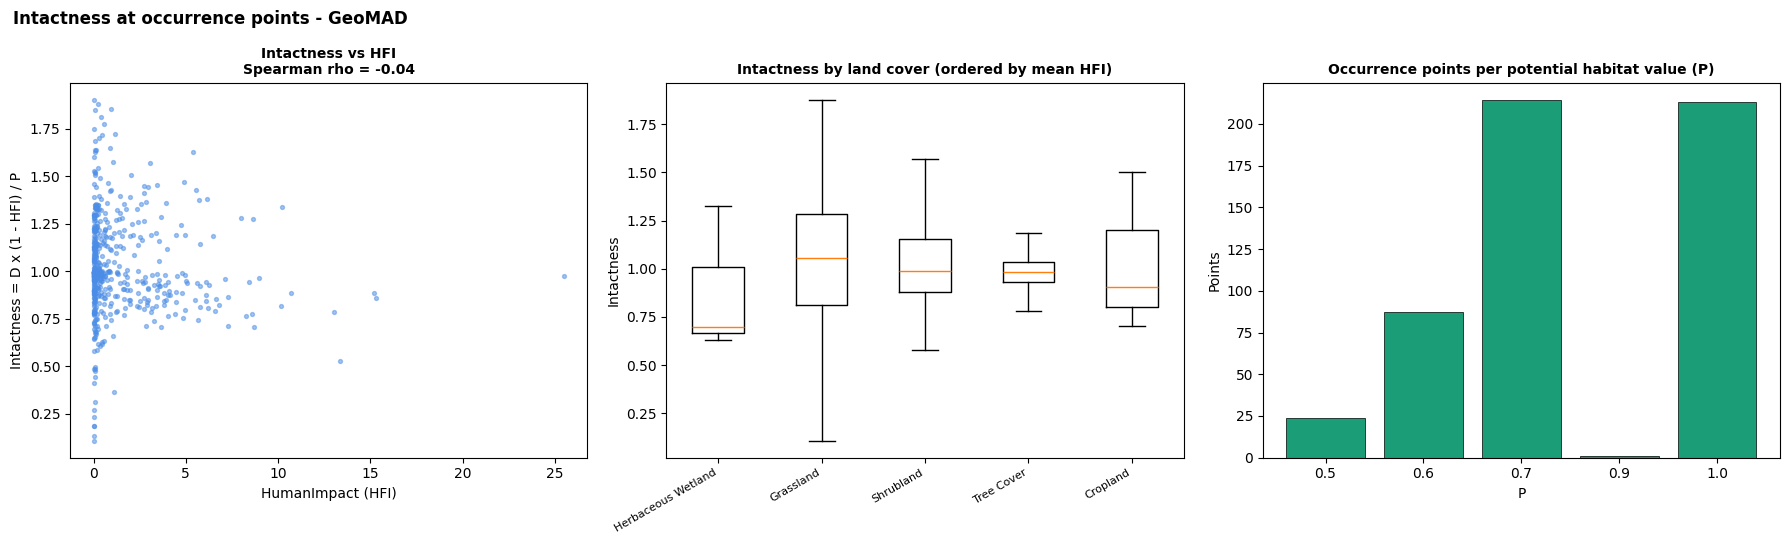

[run]  GeoMAD_Climate_Canopy_HF


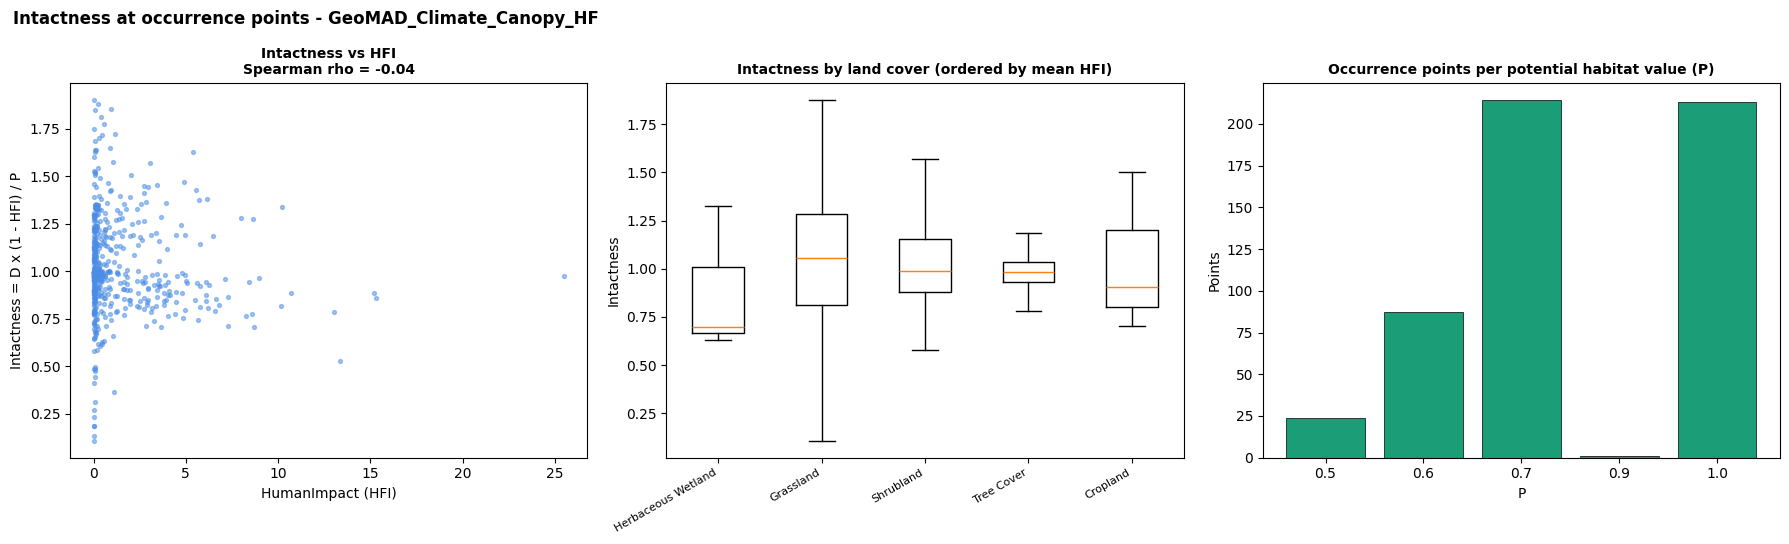

[run]  TCI


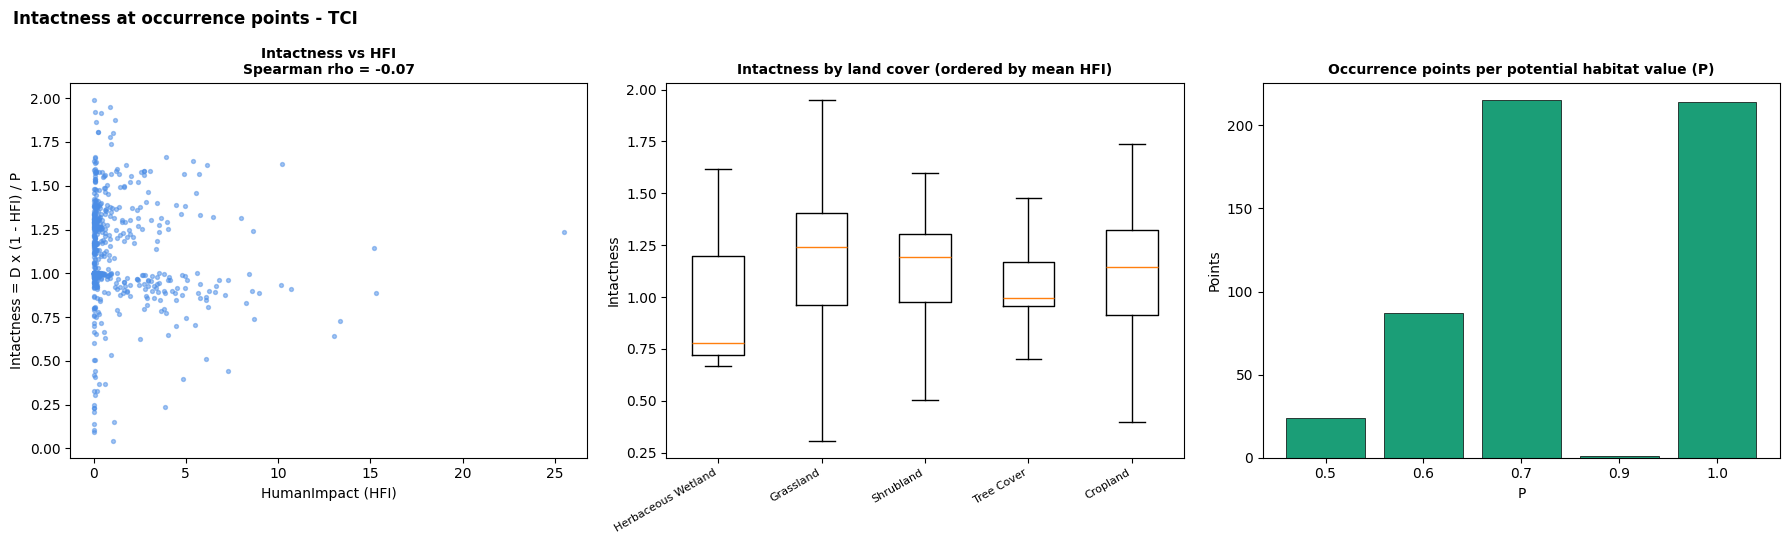

[run]  TCI_Climate_Canopy_HF


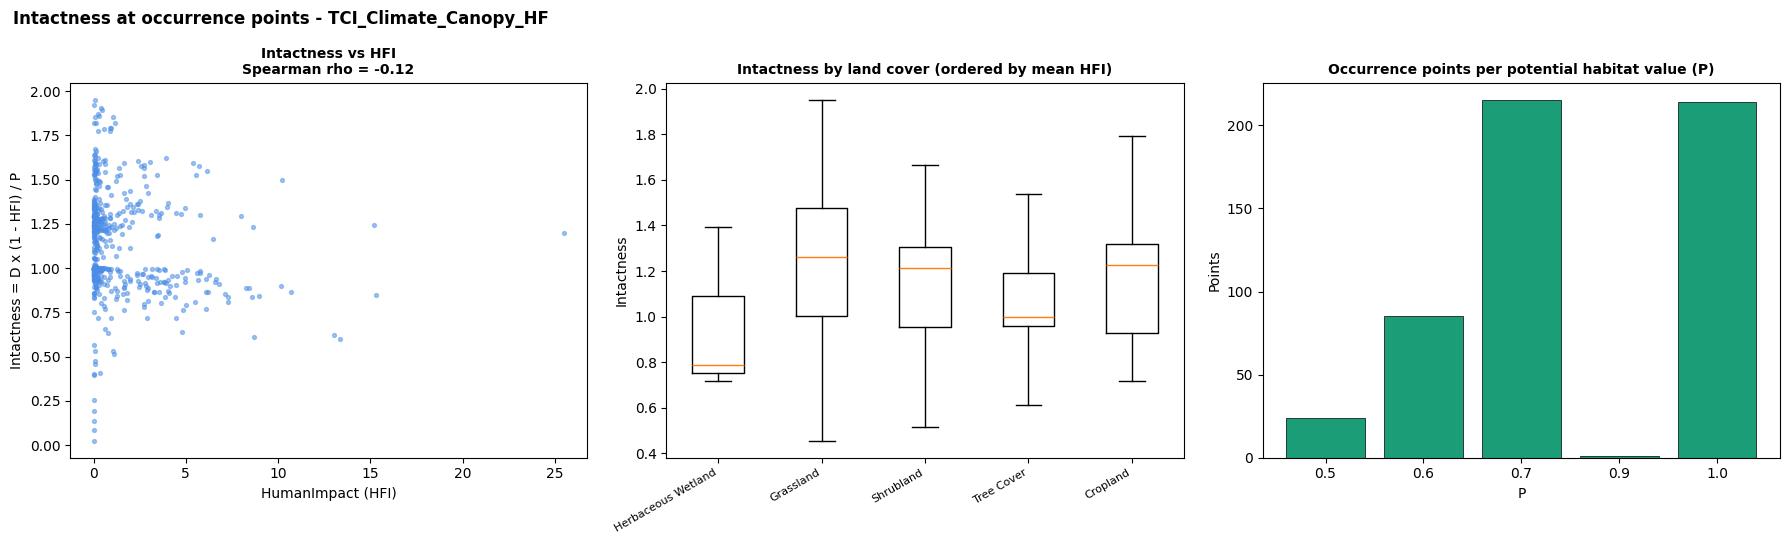

,Scenario,Index,median,pct_in_0_1,spearman_vs_HFI,TreeCover_mean,Cropland_mean,pass_range,pass_decreases_with_HFI,pass_Tree_gt_Crop
0,GeoMAD,D x (1 - HFI) / P,0.987,59.555,-0.043,1.028,1.021,False,False,True
1,GeoMAD_Climate_Canopy_HF,D x (1 - HFI) / P,0.987,59.555,-0.043,1.028,1.021,False,False,True
2,TCI,D x (1 - HFI) / P,1.060,48.059,-0.072,1.059,1.148,False,False,False
3,TCI_Climate_Canopy_HF,D x (1 - HFI) / P,1.120,46.197,-0.122,1.069,1.152,False,True,False


In [9]:
if not os.path.exists(POTENTIAL_HABITAT_TIF):
    raise FileNotFoundError(f"POTENTIAL_HABITAT_TIF not found: {POTENTIAL_HABITAT_TIF} - set it in the cell above")
if not os.path.exists(HUMAN_IMPACT_TIF):
    raise FileNotFoundError(f"HUMAN_IMPACT_TIF not found: {HUMAN_IMPACT_TIF} - set it in section 1")

occ_intact = pd.read_csv(OCCURRENCE_FILE)
missing_cols = {"longitude", "latitude", "landcover_name"} - set(occ_intact.columns)
if missing_cols:
    raise ValueError(f"Occurrence CSV is missing columns: {missing_cols}")

hfi_min, hfi_max = hfi_raster_range()
occ_intact["HFI"] = sample_raster(HUMAN_IMPACT_TIF, occ_intact.longitude, occ_intact.latitude)
n_no_hfi = occ_intact.HFI.isna().sum()
if n_no_hfi:
    log(f"{n_no_hfi} of {len(occ_intact)} occurrence points have no Human Impact value and are dropped")

occ_intact["P"] = sample_potential(occ_intact.longitude, occ_intact.latitude)
n_no_p = occ_intact.P.isna().sum()
if n_no_p:
    log(f"{n_no_p} of {len(occ_intact)} occurrence points have no potential habitat value (P = NaN) and are dropped")

log(f"{len(occ_intact)} occurrence points, HFI raster range {hfi_min:.1f} - {hfi_max:.1f}")

intactness_summaries = []
for scenario_name in SCENARIO_NAMES:
    tif = os.path.join(OUTPUT_BASE_DIR, scenario_name, f"{scenario_name}_Insect_Diversity.tif")
    if not os.path.exists(tif):
        log(f"[skip] {scenario_name}: {tif} not found")
        continue
    log(f"[run]  {scenario_name}")
    summary = run_intactness_scenario(occ_intact, scenario_name, tif, hfi_min, hfi_max)
    if summary is not None:
        intactness_summaries.append(summary)

if intactness_summaries:
    intactness_checks = pd.concat(intactness_summaries, ignore_index=True)
    intactness_checks.to_csv(os.path.join(INTACTNESS_DIR, "Intactness_checks.csv"), index=False)
    display(intactness_checks[["Scenario", "Index", "median", "pct_in_0_1", "spearman_vs_HFI",
                               "TreeCover_mean", "Cropland_mean", "pass_range",
                               "pass_decreases_with_HFI", "pass_Tree_gt_Crop"]].round(3))
else:
    log("No diversity rasters found; nothing to evaluate.")

### 6b. Intactness maps

**Intactness = (D x (1 - HFI)) / P** computed for every pixel of each scenario's diversity map grid
(EPSG:4326, 250 m):

- **D** = the scenario's `<scenario>_Insect_Diversity.tif`
- **HFI** = `HUMAN_IMPACT_TIF` resampled onto that grid (bilinear), scaled 0-1 with the raster range from section 6
- **P** = `POTENTIAL_HABITAT_TIF` resampled onto that grid (nearest) and reclassified with `POTENTIAL_RECLASS`

Pixels missing any of the three are NoData. Saved per scenario in `Intactness_Exploration/<scenario>/`:
`<scenario>_Intactness.tif`, `<scenario>_HFI.tif` (raw, on the grid), `<scenario>_Potential_habitat_P.tif`
and `Intactness_map.png`; the pixel-level checks go to `Intactness_checks_map.csv`. Run section 6 first.

In [10]:
def read_onto_grid(path, dst_transform, dst_shape, resampling):
    """Reads band 1 of any raster and reprojects it onto the diversity map grid (EPSG:4326)."""
    dest = np.full(dst_shape, np.nan, dtype="float32")
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        reproject(source=arr, destination=dest, src_transform=src.transform, src_crs=src.crs,
                  dst_transform=dst_transform, dst_crs="EPSG:4326", resampling=resampling,
                  src_nodata=np.nan, dst_nodata=np.nan)
    return dest


def save_intactness_map(scenario, hfi_min, hfi_max, n_sample=200_000):
    div_tif = os.path.join(OUTPUT_BASE_DIR, scenario, f"{scenario}_Insect_Diversity.tif")
    if not os.path.exists(div_tif):
        log(f"[skip] {scenario}: {div_tif} not found")
        return None

    with rasterio.open(div_tif) as src:
        D = src.read(1, masked=True).filled(np.nan).astype("float32")
        grid_transform = src.transform
        profile = src.profile.copy()
    shape = D.shape
    HFI = read_onto_grid(HUMAN_IMPACT_TIF, grid_transform, shape, Resampling.bilinear)
    P = reclass_potential(read_onto_grid(POTENTIAL_HABITAT_TIF, grid_transform, shape, Resampling.nearest))

    hfi_norm = np.clip((HFI - hfi_min) / (hfi_max - hfi_min), 0, 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        intactness = D * (1 - hfi_norm) / P
    intactness = np.where(np.isfinite(intactness), intactness, np.nan).astype("float32")

    out_dir = os.path.join(INTACTNESS_DIR, scenario)
    os.makedirs(out_dir, exist_ok=True)
    profile.update(count=1, dtype="float32", nodata=np.nan, compress="deflate")
    for name, arr in [("Intactness", intactness), ("HFI", HFI), ("Potential_habitat_P", P)]:
        with rasterio.open(os.path.join(out_dir, f"{scenario}_{name}.tif"), "w", **profile) as dst:
            dst.write(arr.astype("float32"), 1)

    valid = np.isfinite(intactness)
    if not valid.any():
        log(f"  [skip] {scenario}: no pixel has D, HFI and P all present")
        return None
    vals = intactness[valid]
    in_0_1 = (vals >= 0) & (vals <= 1)
    # Spearman on a random pixel sample - the full grid is millions of pixels
    idx = np.random.default_rng(RNG_SEED).choice(vals.size, size=min(n_sample, vals.size), replace=False)
    rho, pval = spearmanr(HFI[valid][idx], vals[idx])
    summary = {
        "Scenario": scenario, "Valid_pixels": int(vals.size),
        "min": float(vals.min()), "median": float(np.median(vals)), "max": float(vals.max()),
        "mean": float(vals.mean()), "pct_in_0_1": 100 * float(in_0_1.mean()),
        "spearman_vs_HFI": rho, "spearman_p": pval,
        "pass_range": in_0_1.mean() >= 0.9,
        "pass_decreases_with_HFI": rho < 0 and pval < 0.05,
    }

    left, bottom, right, top = rasterio.transform.array_bounds(shape[0], shape[1], grid_transform)
    extent = (left, right, bottom, top)
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))

    im = axes[0].imshow(D, extent=extent, cmap="viridis")
    fig.colorbar(im, ax=axes[0], shrink=0.8, label="D")
    axes[0].set_title("D - current diversity", fontweight="bold", fontsize=10)

    im = axes[1].imshow(HFI, extent=extent, cmap="magma_r")
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="HFI")
    axes[1].set_title("HFI - human impact", fontweight="bold", fontsize=10)

    im = axes[2].imshow(P, extent=extent, cmap="YlGn", vmin=POTENTIAL_MIN, vmax=POTENTIAL_MAX)
    fig.colorbar(im, ax=axes[2], shrink=0.8, label="P")
    axes[2].set_title("P - potential habitat", fontweight="bold", fontsize=10)

    # colour range from the 2nd-98th percentile so outliers don't wash it out
    vmin, vmax = np.percentile(vals, [2, 98])
    im = axes[3].imshow(intactness, extent=extent, cmap="RdYlGn", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=axes[3], shrink=0.8, label="Intactness")
    axes[3].set_title("Intactness = D x (1 - HFI) / P", fontweight="bold", fontsize=10)

    for ax in axes:
        ax.set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    fig.suptitle(f"Intactness map - {scenario}", fontweight="bold", x=0.01, ha="left")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "Intactness_map.png"), dpi=200)
    plt.show()
    plt.close(fig)
    log(f"  {vals.size} pixels, intactness mean={vals.mean():.4f}, median={np.median(vals):.4f}, "
        f"Spearman vs HFI={rho:.3f}")
    return summary


[map] GeoMAD


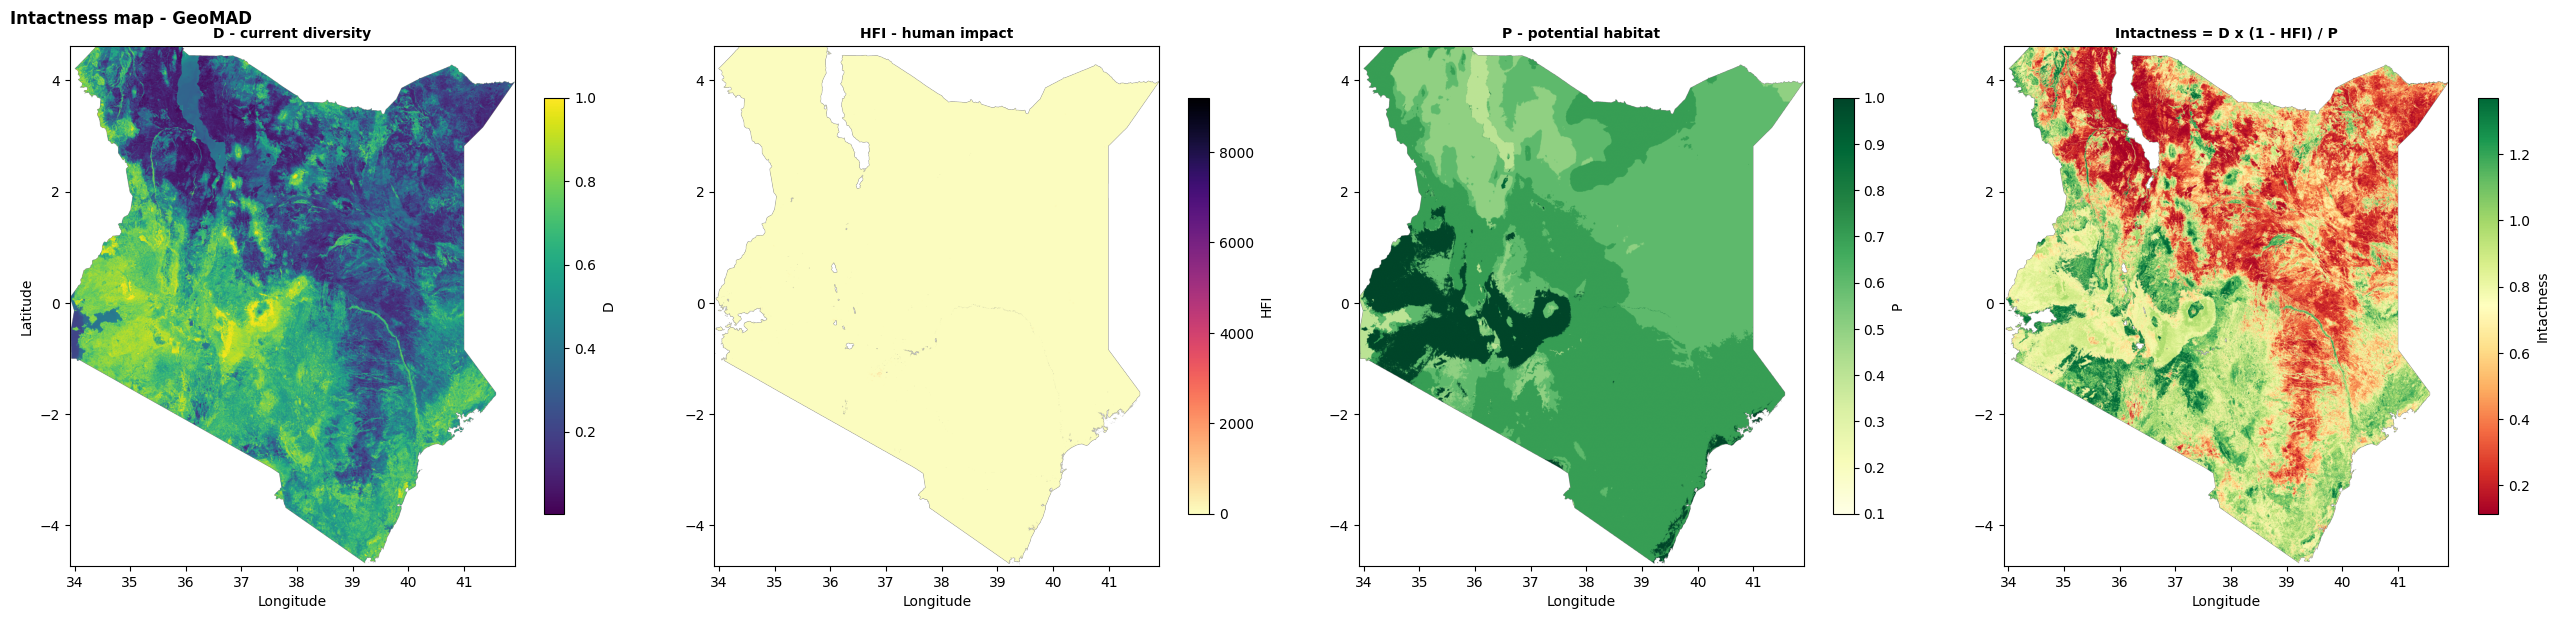

  9852679 pixels, intactness mean=0.6819, median=0.7104, Spearman vs HFI=0.238
[map] GeoMAD_Climate_Canopy_HF


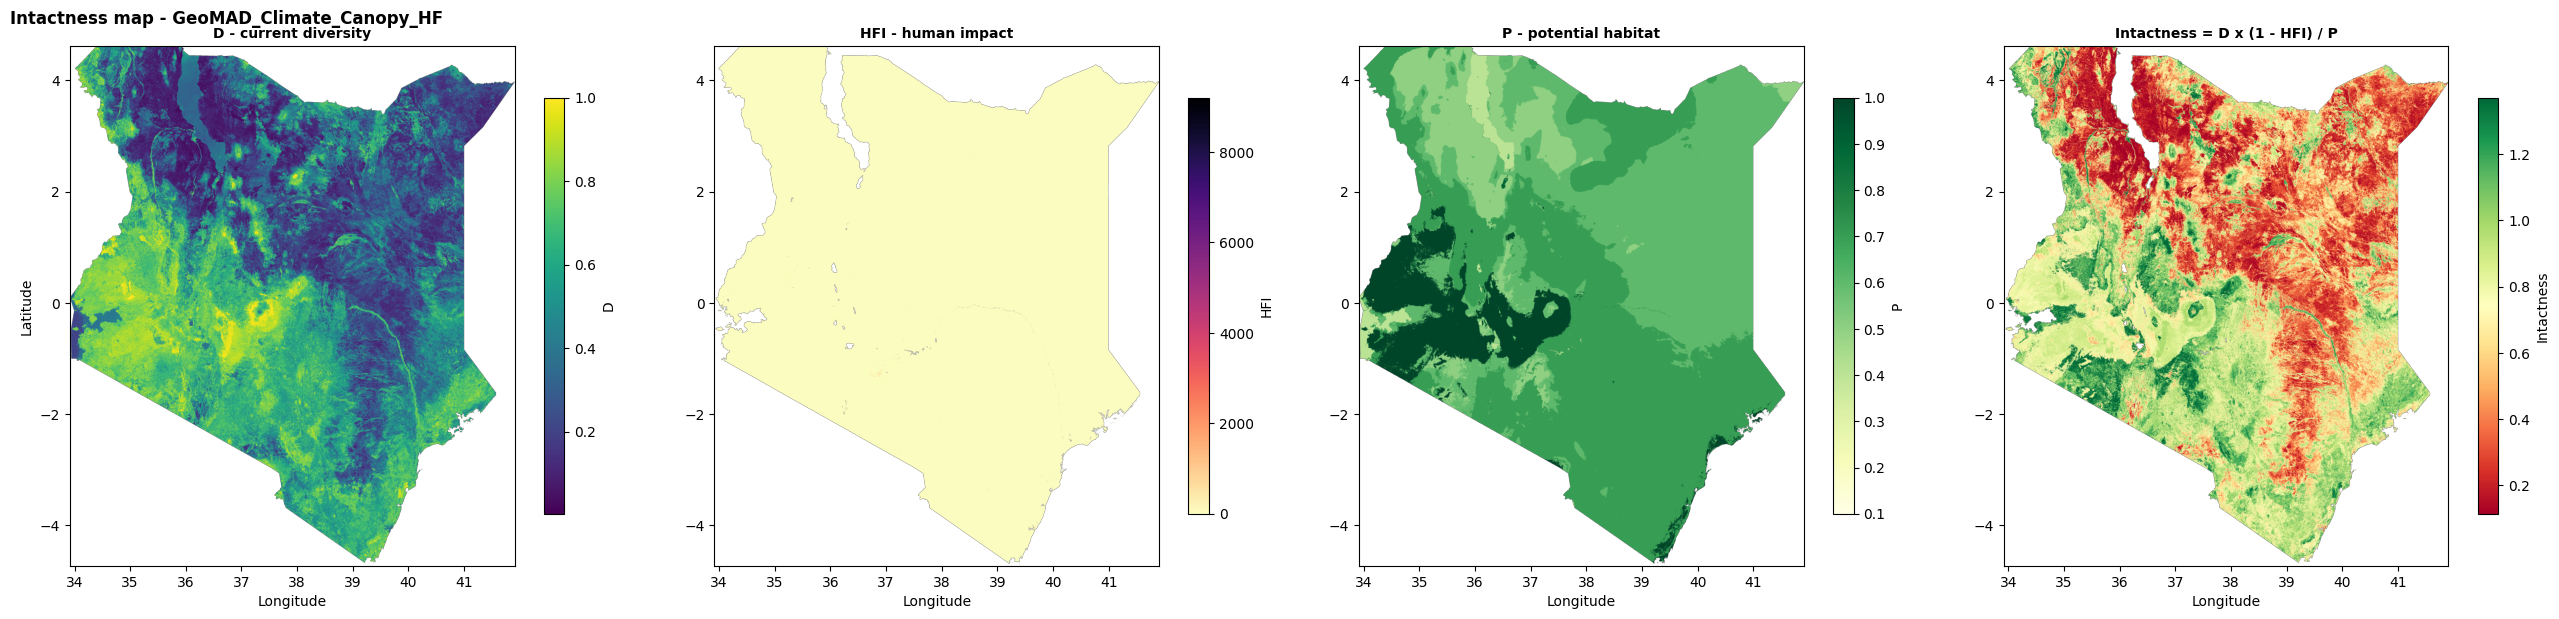

  9852679 pixels, intactness mean=0.6819, median=0.7104, Spearman vs HFI=0.238
[map] TCI


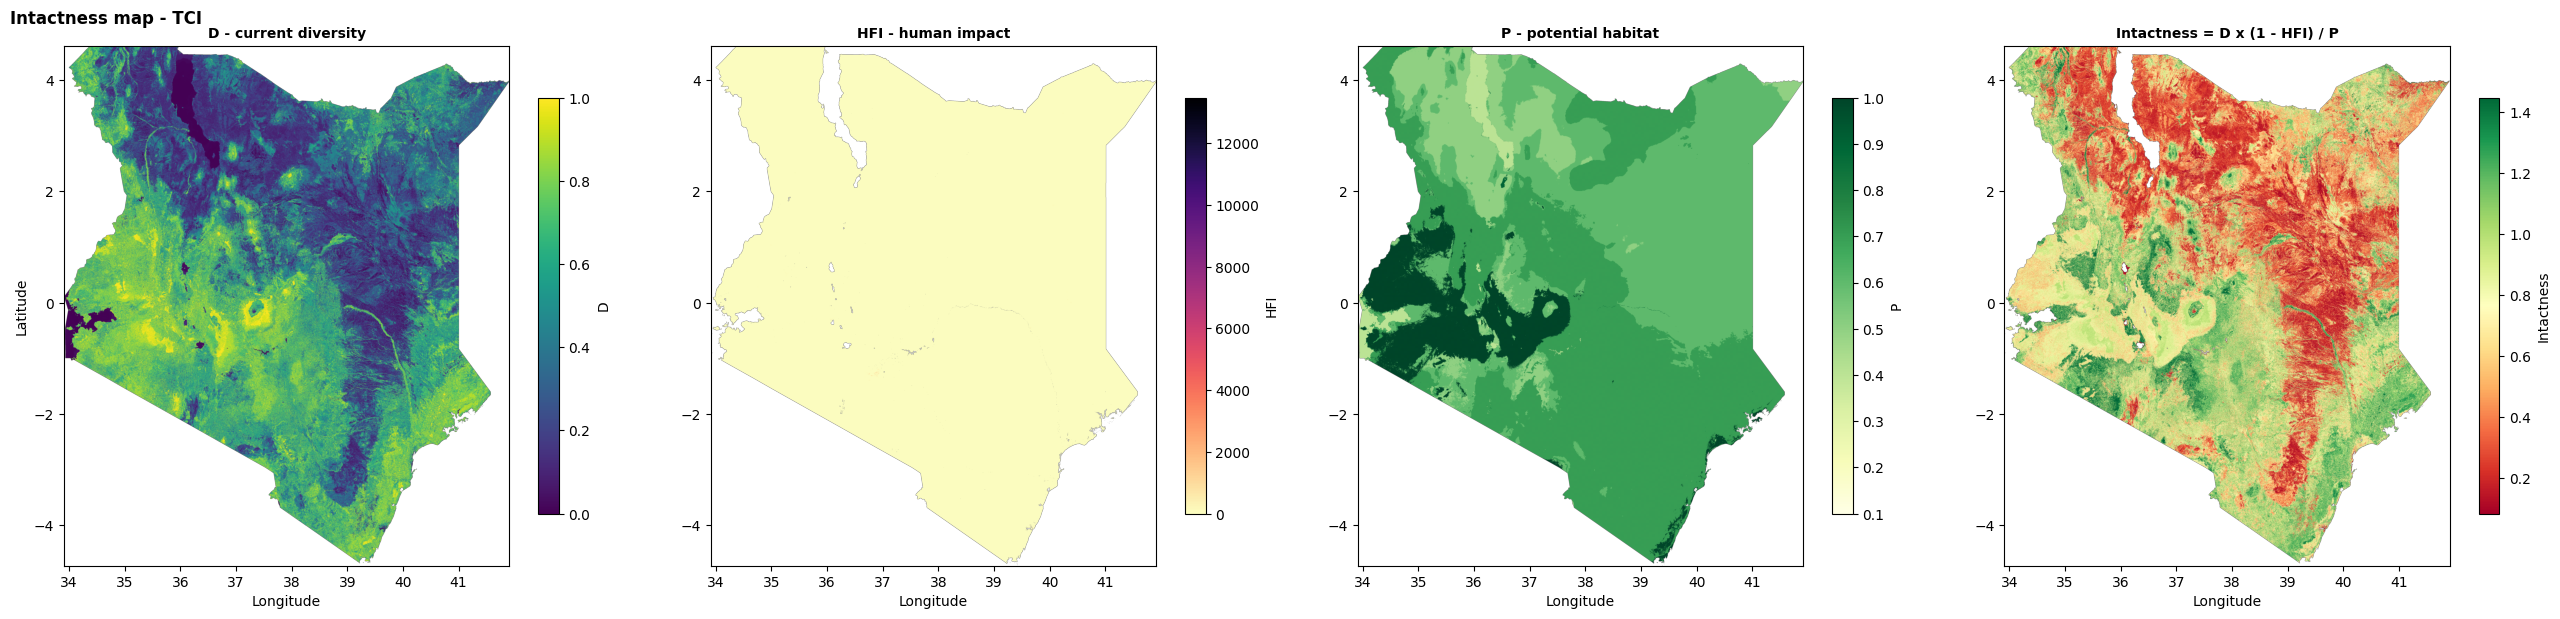

  9184025 pixels, intactness mean=0.7079, median=0.7114, Spearman vs HFI=0.246
[map] TCI_Climate_Canopy_HF


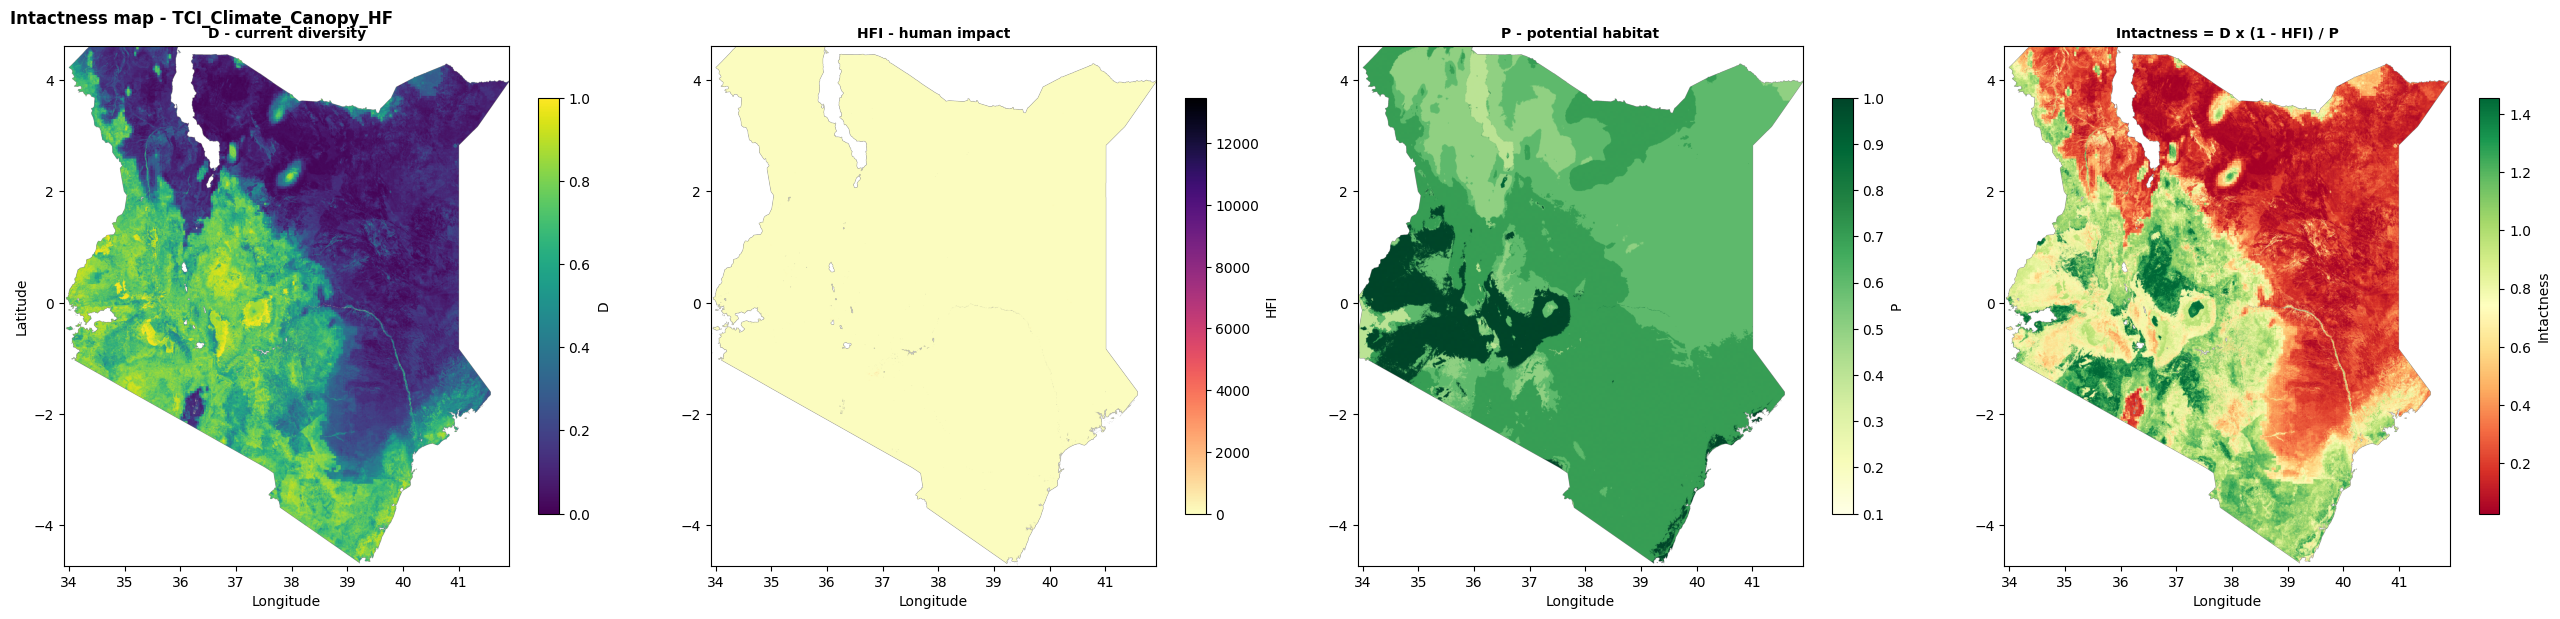

  9175756 pixels, intactness mean=0.5680, median=0.4914, Spearman vs HFI=0.278


,Scenario,Valid_pixels,min,median,max,mean,pct_in_0_1,spearman_vs_HFI,spearman_p,pass_range,pass_decreases_with_HFI
0,GeoMAD,9852679,0.007,0.710,7.093,0.682,82.069,0.238,0.0,False,False
1,GeoMAD_Climate_Canopy_HF,9852679,0.007,0.710,7.093,0.682,82.069,0.238,0.0,False,False
2,TCI,9184025,0.000,0.711,3.380,0.708,77.207,0.246,0.0,False,False
3,TCI_Climate_Canopy_HF,9175756,0.000,0.491,7.460,0.568,80.782,0.278,0.0,False,False


In [11]:
map_summaries = []
for scenario_name in SCENARIO_NAMES:
    log(f"[map] {scenario_name}")
    s = save_intactness_map(scenario_name, hfi_min, hfi_max)
    if s is not None:
        map_summaries.append(s)

if map_summaries:
    map_checks = pd.DataFrame(map_summaries)
    map_checks.to_csv(os.path.join(INTACTNESS_DIR, "Intactness_checks_map.csv"), index=False)
    display(map_checks.round(3))
else:
    log("No scenario produced an intactness map.")